In [2]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

sys.path.append(os.path.expanduser('~/git/desi-examples/misc/plot_spectrum/'))
import desi_plot_spectrum

In [3]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
# cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

mask = cat['subset']==1
cat = cat[mask]
print(len(cat))

mask = cat['main_lrg'].copy()
cat = cat[mask]
print(len(cat))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_quality = ((cat['DELTACHI2']>d) & (cat['DELTACHI2']>10)) | (cat['DELTACHI2']>30)
mask_quality &= cat['Z']<1.4
mask_quality &= cat['ZWARN']<1.4
print('Quality', np.sum(mask_quality), np.sum(~mask_quality), np.sum(mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

mask = cat['PHOTSYS']=='S'
cat = cat[mask]
print(len(cat))

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194
Min depth 22883 1610 0.9342669334095456
4015
1076
Quality 1067 9 0.991635687732342
1067
690


In [5]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
# deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Require a minimum depth
min_depth = 8000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
39533 39533
Min depth 2639 36894 0.06675435711936863


In [6]:
tid = np.intersect1d(cat['TARGETID'], deep['TARGETID'])

mask = np.in1d(cat['TARGETID'], tid)
cat = cat[mask]

mask = np.in1d(deep['TARGETID'], tid)
deep = deep[mask]

cat.sort('TARGETID')
deep.sort('TARGETID')

print(len(cat), len(np.unique(cat['TARGETID'])))
print(np.all(cat['TARGETID']==deep['TARGETID']))

160 160
True


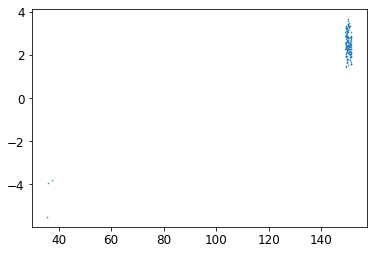

In [7]:
plt.plot(cat['TARGET_RA'], cat['TARGET_DEC'], '.', ms=1, alpha=1)

In [8]:
np.random.seed(706846)
idx = np.random.choice(len(cat), size=7, replace=False)

In [9]:
cat['Z'][idx]-deep['Z'][idx]

0.00022784990123214666
0.00028782399925320057
4.7184439240260945e-05
0.00012342518352403964
5.615050596896598e-05
7.081977165235287e-05
-0.0001969952189112001


In [10]:
cat[idx]

TARGETID,Z,ZERR,ZWARN,CHI2,SPECTYPE,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FIBERFLUX_Z,MASKBITS,PARALLAX,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,fn,subset,lrg_mask,main_lrg,EFFTIME_ELG,EFFTIME_LRG
int64,float64,float64,int64,float64,str6,float64,int16,int32,int64,int32,int32,float64,float64,str4,float32,float32,float32,float32,float32,float32,float32,int16,float32,str1,int64,int64,int64,int64,int32,int16,float32,int16,int16,float32,float32,float32,float32,str58,int64,int16,bool,float32,float32
39627853687426505,0.821094727628992,0.00013943693730885604,0,7468.136659361422,GALAXY,196.65444508939981,6,64,6064,3211,0,150.39770187522046,2.770040818835769,DEV,0.019961357,0.24166517,1.3029534,7.906499,31.348555,17.772774,3.219352,0,0.0,S,125829241,0,0,0,80609,2,1800.0,2,1,118.840805,7432.964,31.65094,85.90113,fuji/tiles/1x_depth/80609/1/redrock-6-80609-1xsubset1.fits,1,0,True,1022.03094,1043.6987
39627847639241922,0.7252063108745384,9.032676684419649e-05,0,7759.355464436114,GALAXY,300.9740127772093,4,6,4006,2131,0,149.98096875555134,2.387833624381869,DEV,0.017867766,0.306643,2.0388365,9.651571,34.00779,20.19467,4.9347343,0,0.0,S,125829241,0,0,0,80609,2,1800.0,2,1,125.87226,8174.6704,33.476143,89.92689,fuji/tiles/1x_depth/80609/1/redrock-4-80609-1xsubset1.fits,1,0,True,1082.5015,1092.6117
39627841586860064,0.21050480469174399,1.7643657707861095e-05,0,8140.773198664188,GALAXY,972.578544517979,3,152,3152,1573,0,149.18907810698684,2.333444046548214,SER,0.018568648,5.7060585,17.052517,38.02703,98.106094,86.61768,8.764538,0,0.0,S,1152921504724287601,131074,0,0,80609,2,1800.0,2,1,119.96256,7872.4194,31.983074,85.023026,fuji/tiles/1x_depth/80609/1/redrock-3-80609-1xsubset1.fits,1,0,True,1031.6781,1033.0298
39627841595249684,1.0295306412998189,0.00012978208372567057,0,8023.0950918495655,GALAXY,126.80397375673056,3,36,3036,1547,0,149.711634295558,2.365208379316656,REX,0.02127004,0.39151415,0.9799778,3.5493531,21.665308,20.319569,2.367131,0,0.0,S,67108929,0,0,0,80609,2,1800.0,2,1,121.93388,7922.583,32.482933,86.008865,fuji/tiles/1x_depth/80609/1/redrock-3-80609-1xsubset1.fits,1,0,True,1048.6315,1045.0077
39627871790042996,0.9576820805002297,0.00011349743210703624,0,7774.537983208895,GALAXY,286.52999702841043,5,304,5304,2860,0,150.15769836427472,3.4112390191313744,REX,0.024432156,0.14596039,1.0072306,7.0088406,36.367706,25.249334,4.1483912,0,0.0,S,125829241,0,0,0,80609,2,1800.0,2,1,132.14647,8096.927,34.88792,88.2466,fuji/tiles/1x_depth/80609/1/redrock-5-80609-1xsubset1.fits,1,0,True,1136.4597,1072.1962
39627847630853170,0.3718999844921311,4.600869242227284e-05,0,8612.405355386436,GALAXY,2610.0280429646373,3,110,3110,1746,0,149.4791445242339,2.56492569147204,SER,0.020353109,5.1670017,26.878405,62.61092,114.163506,74.217445,18.02826,0,0.0,S,1152921504732676217,131074,0,0,80609,2,1800.0,2,1,124.23839,8091.583,33.61685,87.9848,fuji/tiles/1x_depth/80609/1/redrock-3-80609-1xsubset1.fits,1,0,True,1068.4502,1069.0153
39627859714640292,0.48907374575267143,8.492461890435592e-05,0,7770.359525255859,GALAXY,1015.4906464628875,4,143,4143,2452,0,149.62816551448975,2.9065155935181832,DEV,0.019784018,1.9376217,11.568127,37.24418,97.535934,60.359985,10.260112,0,0.0,S,1152921504732676217,65537,0,0,80609,2,1800.0,2,1,131.09854,8155.668,33.97997,89.915375,fuji/tiles/1x_depth/80609/1/redrock-4-80609-1xsubset1.fits,1,0,True,1127.4475,1092.4718


INFO:spectra.py:285:read_spectra: iotime 31.885 sec to read coadd-6-80609-1xsubset1.fits at 2022-03-03T19:53:43.228724
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-

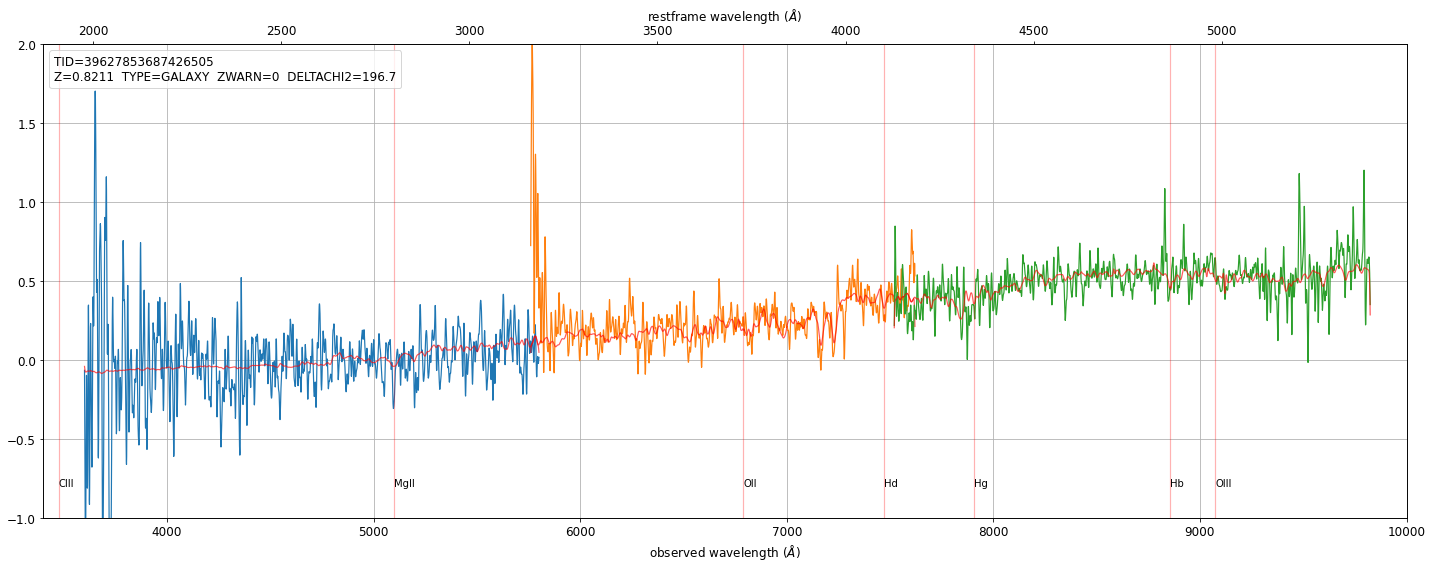

INFO:spectra.py:285:read_spectra: iotime 28.444 sec to read coadd-6-80609-thru20201217.fits at 2022-03-03T19:54:30.245997
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtempla

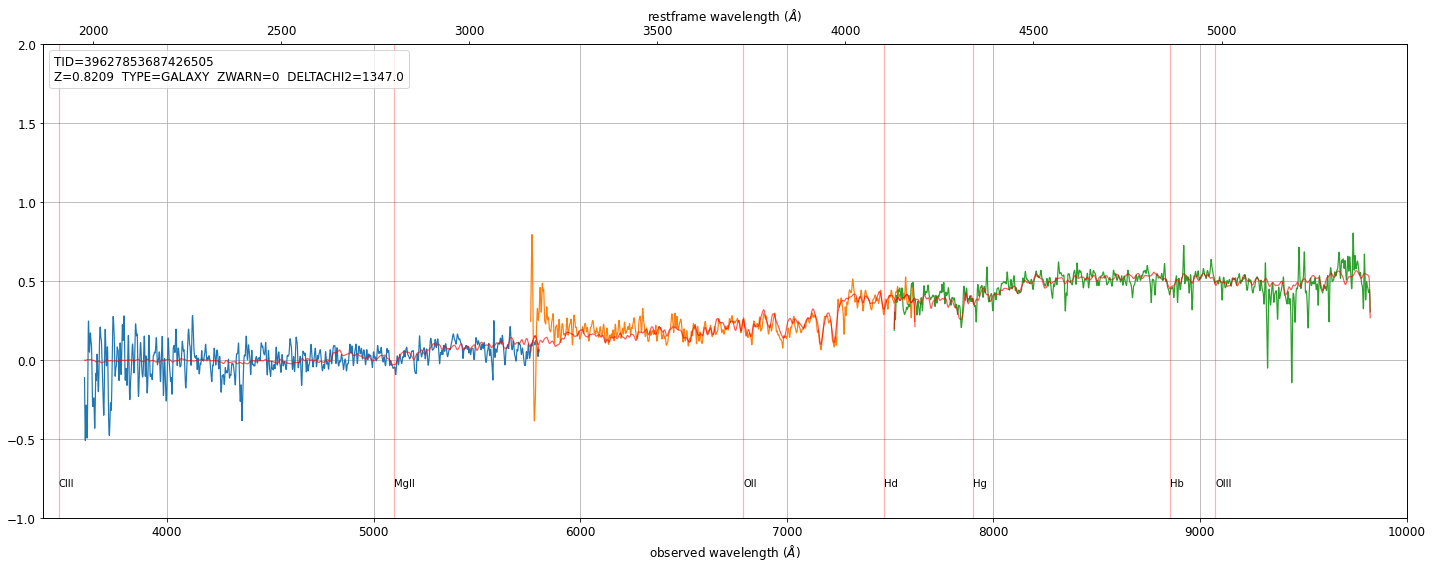

INFO:spectra.py:285:read_spectra: iotime 17.267 sec to read coadd-4-80609-1xsubset1.fits at 2022-03-03T19:54:51.384109
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-

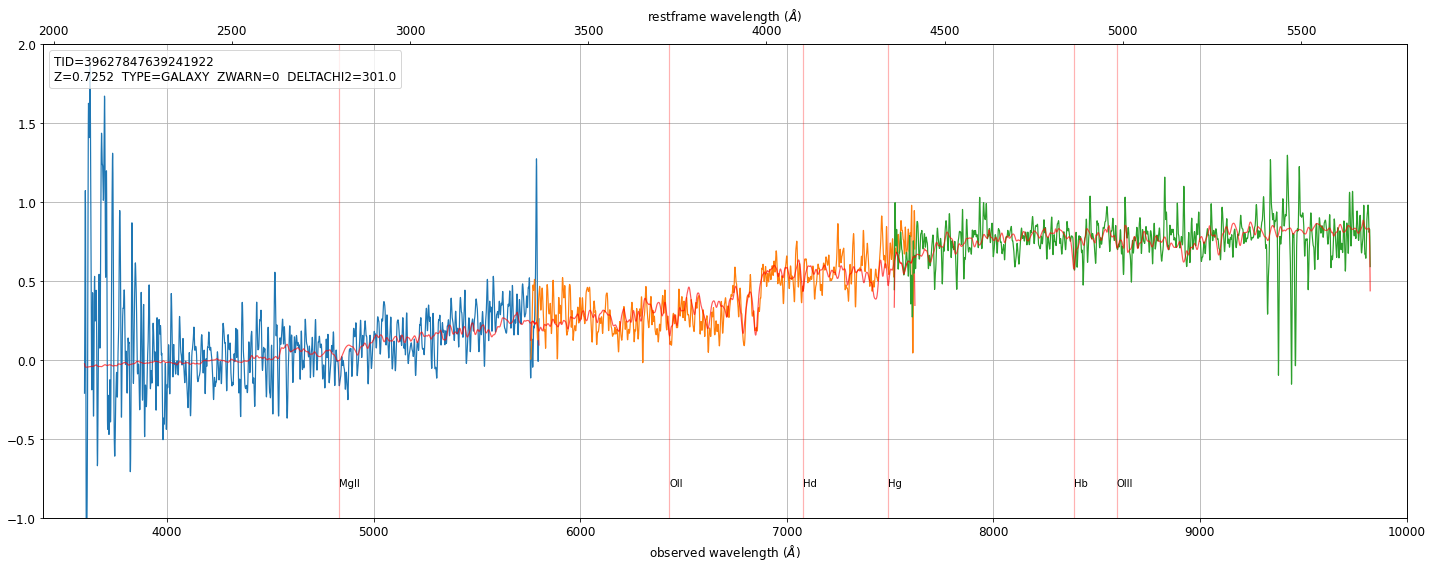

INFO:spectra.py:285:read_spectra: iotime 39.971 sec to read coadd-4-80609-thru20201217.fits at 2022-03-03T19:55:55.762407
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtempla

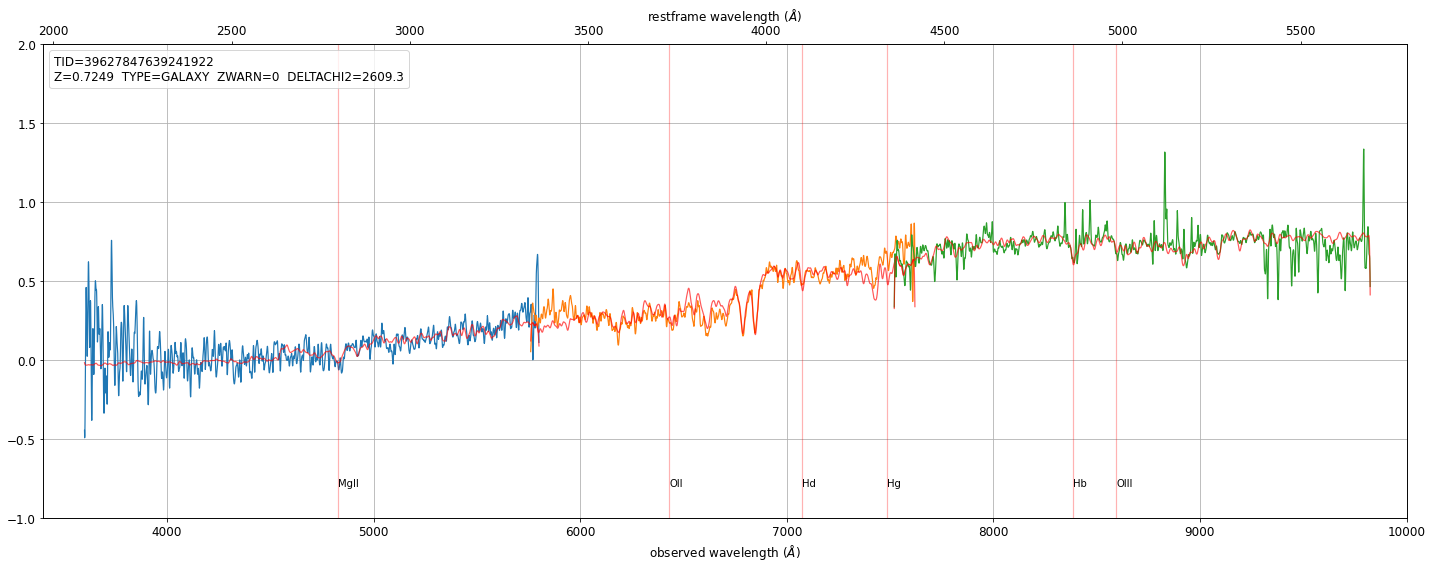

INFO:spectra.py:285:read_spectra: iotime 0.509 sec to read coadd-3-80609-1xsubset1.fits at 2022-03-03T19:55:57.690057
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-s

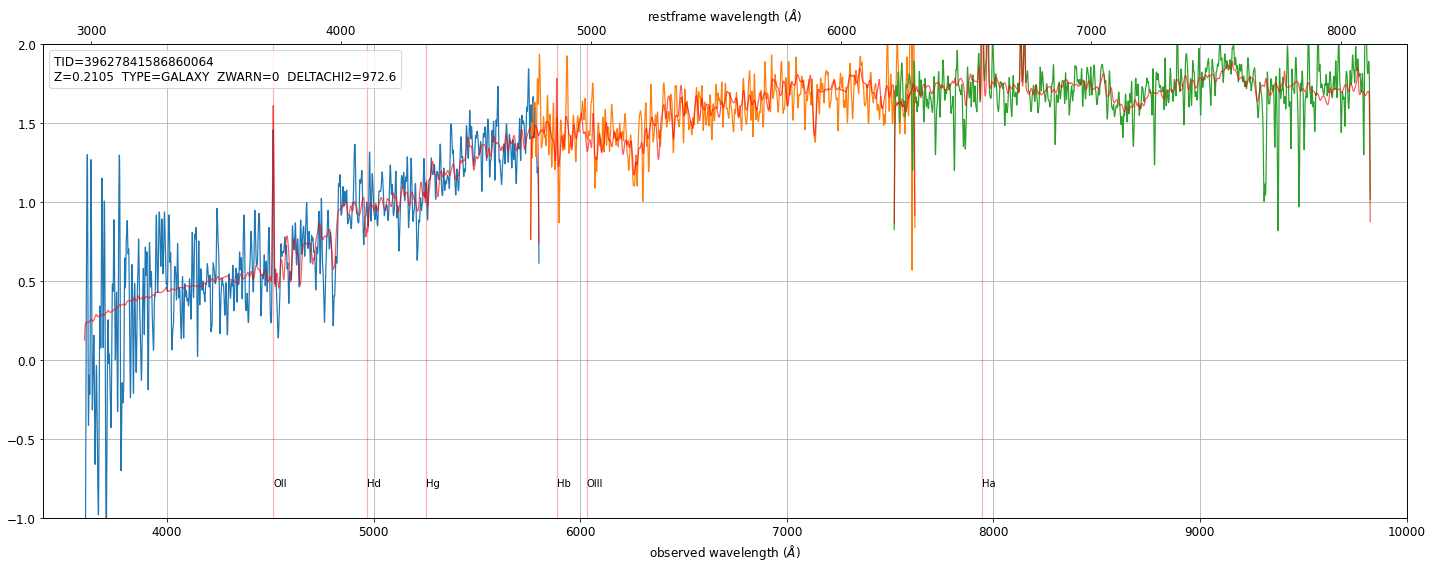

INFO:spectra.py:285:read_spectra: iotime 44.242 sec to read coadd-3-80609-thru20201217.fits at 2022-03-03T19:57:16.546520
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtempla

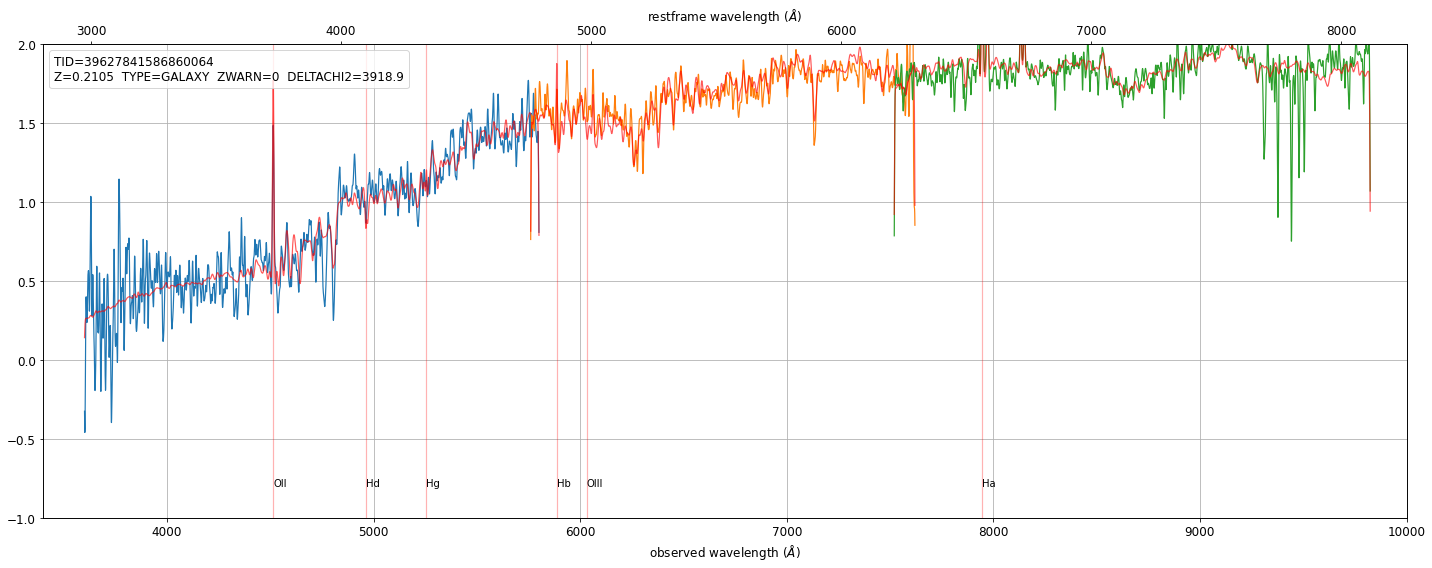

INFO:spectra.py:285:read_spectra: iotime 0.515 sec to read coadd-3-80609-1xsubset1.fits at 2022-03-03T19:57:46.112511
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-s

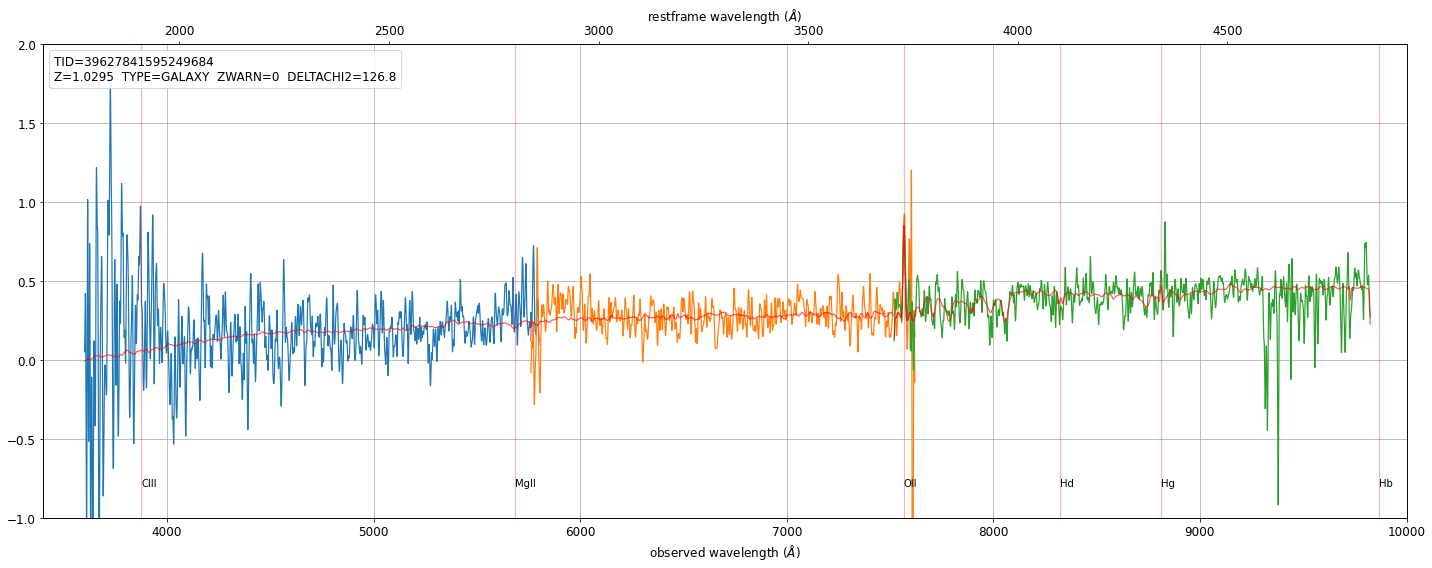

INFO:spectra.py:285:read_spectra: iotime 0.482 sec to read coadd-3-80609-thru20201217.fits at 2022-03-03T19:57:47.751904
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

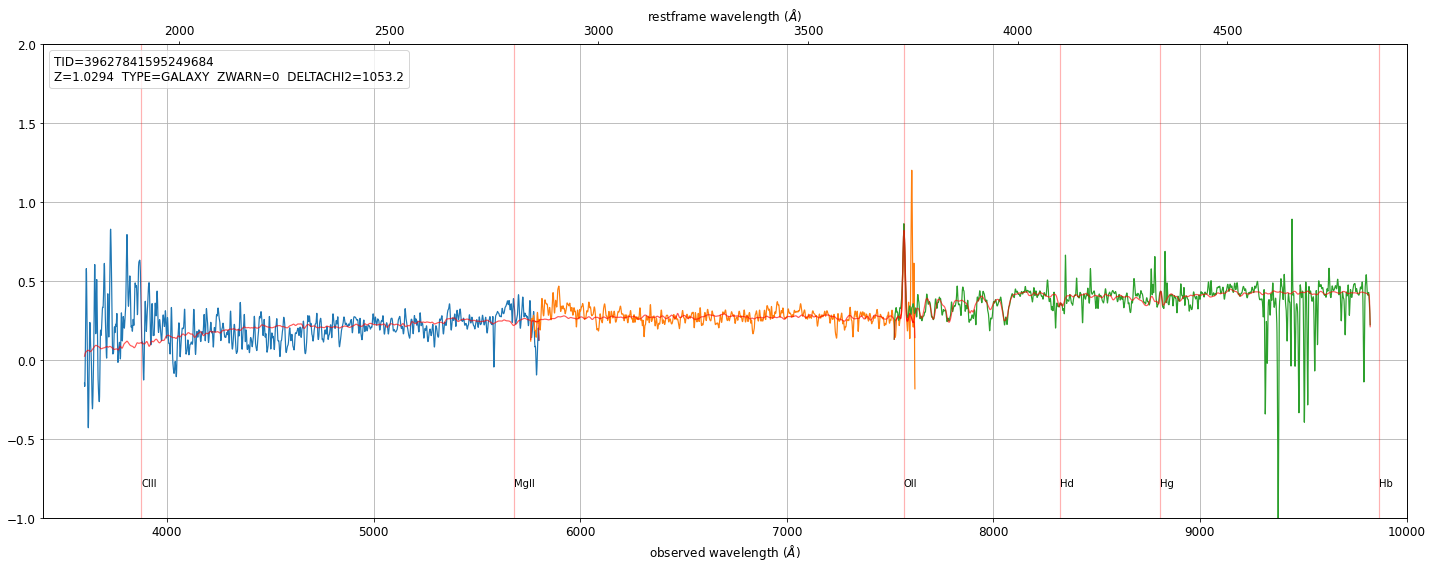

INFO:spectra.py:285:read_spectra: iotime 0.651 sec to read coadd-5-80609-1xsubset1.fits at 2022-03-03T19:57:49.585648
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-s

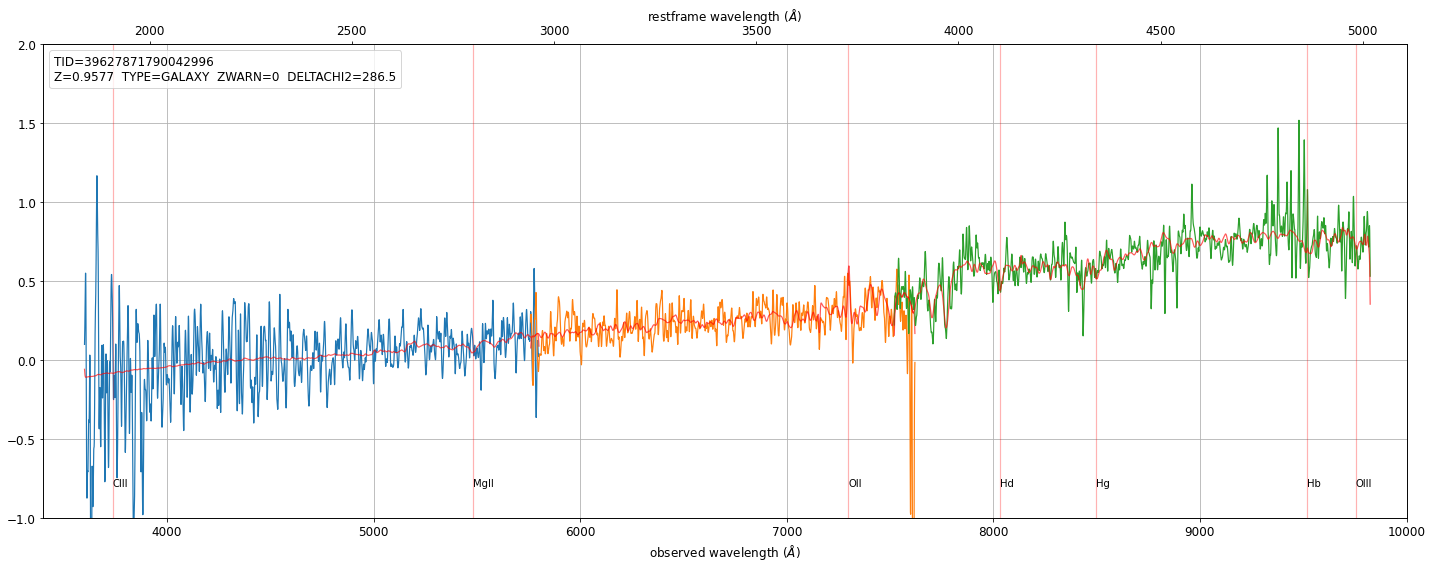

INFO:spectra.py:285:read_spectra: iotime 0.542 sec to read coadd-5-80609-thru20201217.fits at 2022-03-03T19:57:51.573445
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

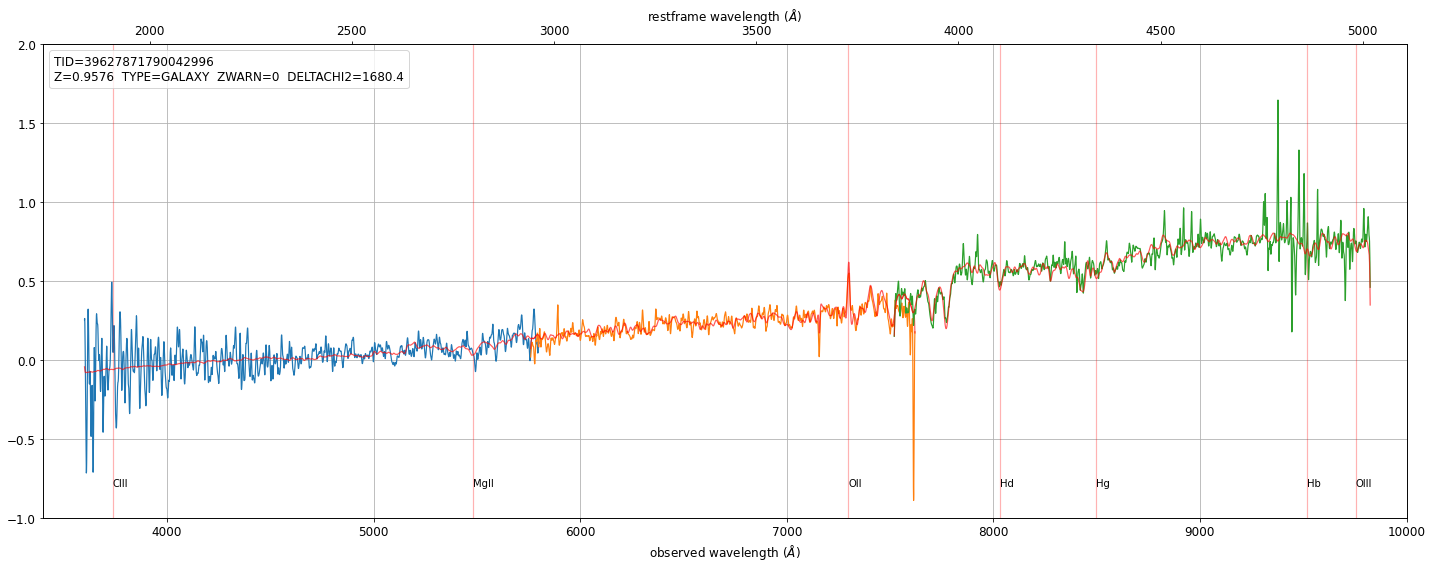

INFO:spectra.py:285:read_spectra: iotime 0.440 sec to read coadd-3-80609-1xsubset1.fits at 2022-03-03T19:57:53.222688
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-s

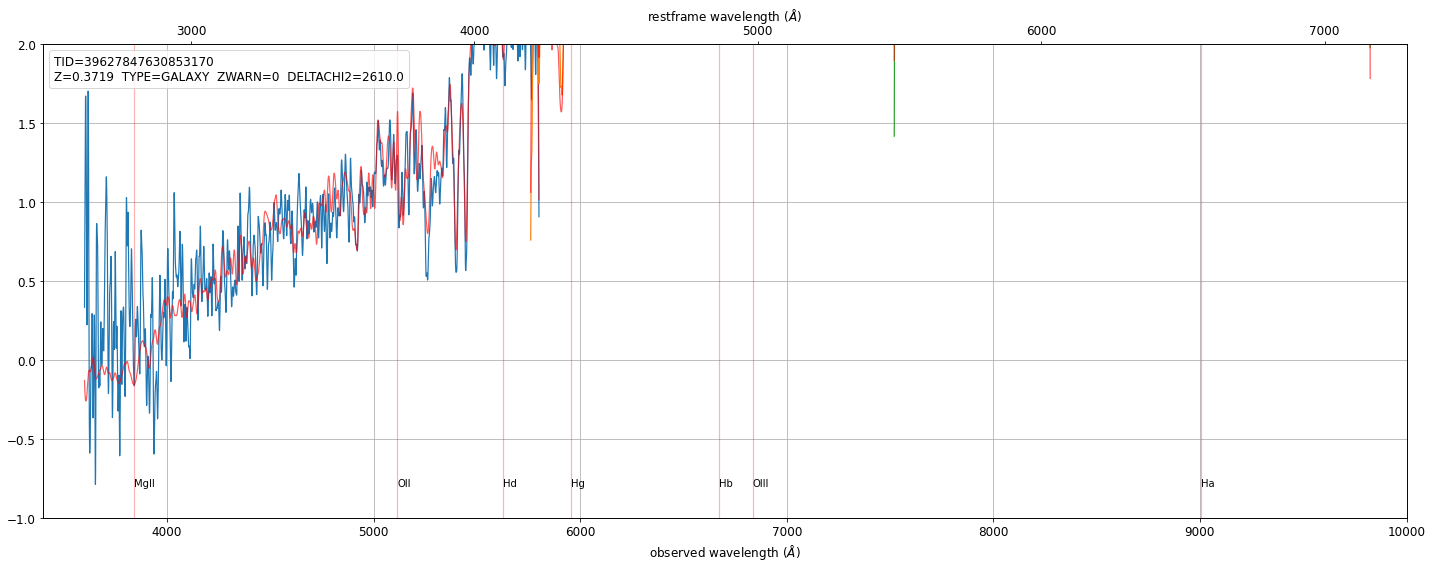

INFO:spectra.py:285:read_spectra: iotime 0.448 sec to read coadd-3-80609-thru20201217.fits at 2022-03-03T19:57:54.793354
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

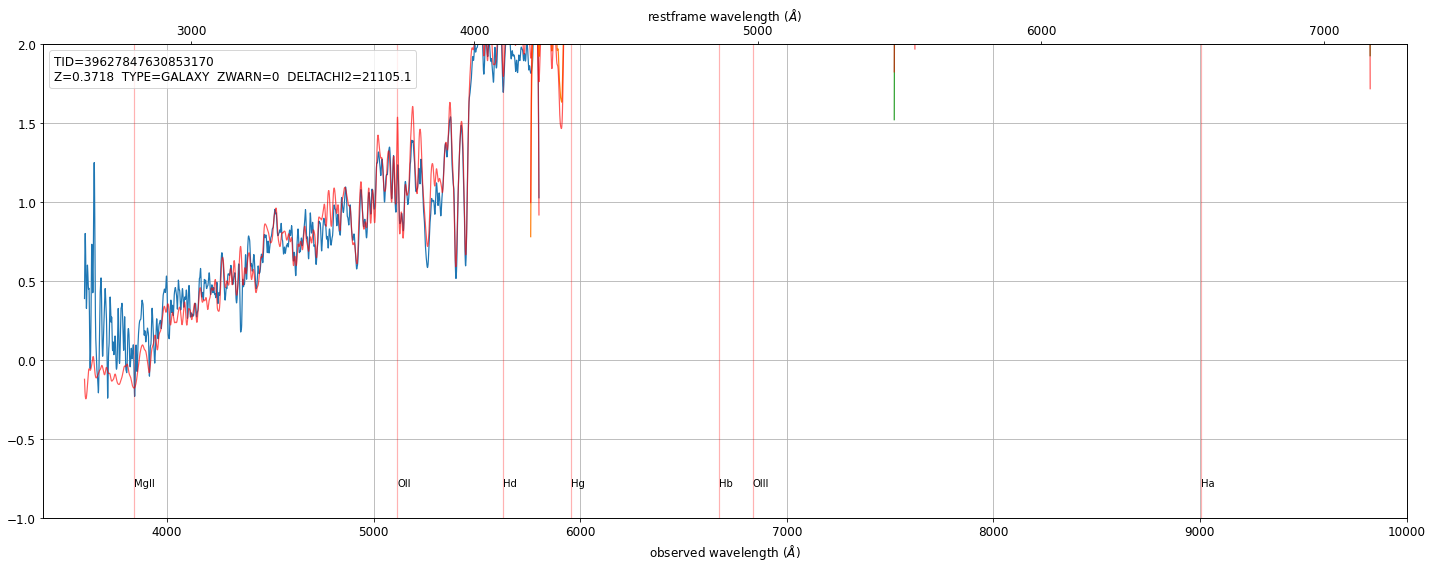

INFO:spectra.py:285:read_spectra: iotime 0.438 sec to read coadd-4-80609-1xsubset1.fits at 2022-03-03T19:57:56.284329
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-s

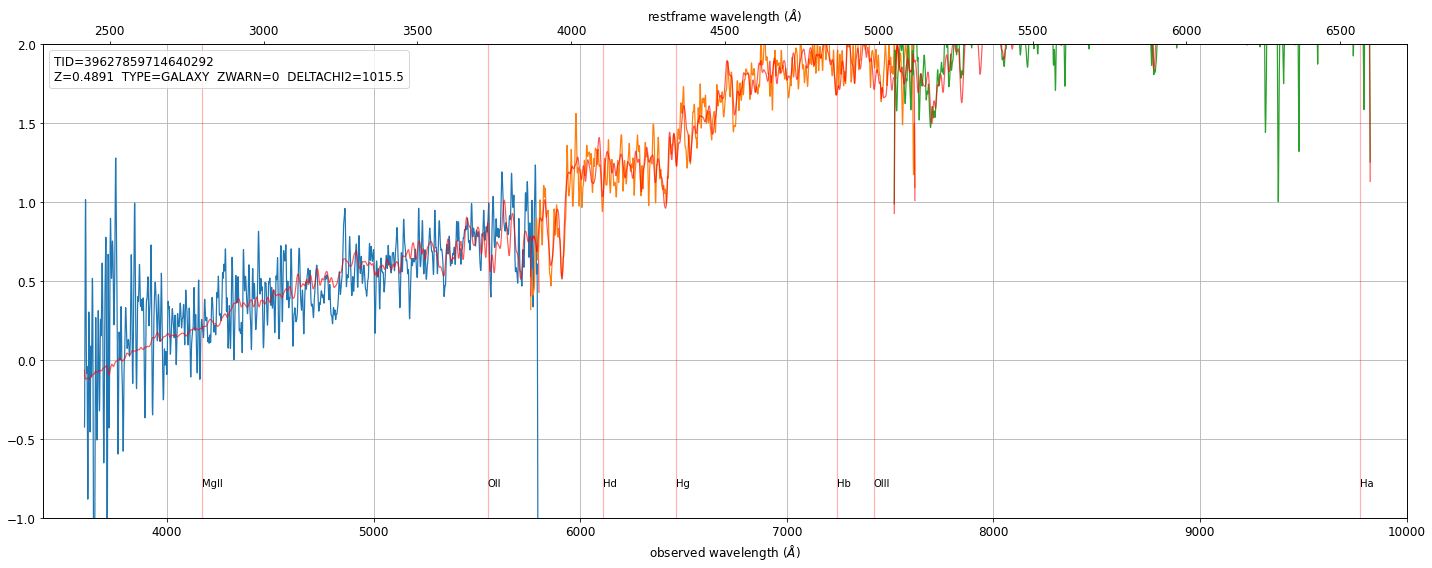

INFO:spectra.py:285:read_spectra: iotime 0.466 sec to read coadd-4-80609-thru20201217.fits at 2022-03-03T19:57:57.897421
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplat

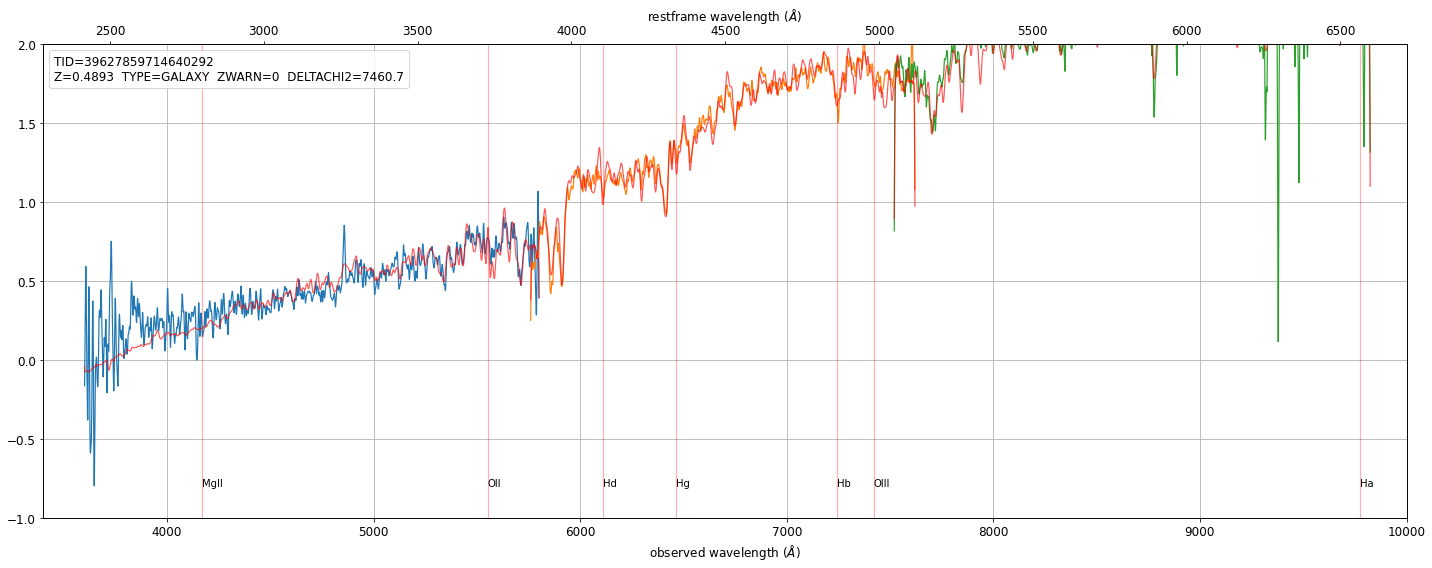

In [11]:
for index in idx:
    desi_plot_spectrum.plot_spectrum('/global/cfs/cdirs/desi/spectro/redux/'+cat['fn'][index].replace('redrock', 'coadd'), cat['TARGETID'][index], use_targetid=True)
    desi_plot_spectrum.plot_spectrum('/global/cfs/cdirs/desi/spectro/redux/'+deep['fn'][index].replace('redrock', 'coadd'), deep['TARGETID'][index], use_targetid=True)